# MVP — Detecção de Fraudes em Cartões de Crédito

**Nome:** _GUILHERME DE ASSIS MELLO_  
**Matrícula:** _4052026000598_  
**Data:** _28/06/2026_  
**Dataset:** Credit Card Fraud Detection — [Kaggle / ULB](https://www.kaggle.com/mlg-ulb/creditcardfraud)  
**Tipo de problema:** Classificação binária (transação legítima × fraude)

---

# 1. Definição do problema

## 1.1 Descrição do problema

Neste projeto, iremos abordar o problema das fraudes em cartões de crédito, uma das principais preocupações das instituições financeiras como bancos e *fintechs*. Apenas no Brasil, cerca de 12,1 milhões de pessoas já foram vítimas de algum tipo de fraude financeira no último ano. Traduzindo em valores, os golpes financeiros ultrapassaram a cifra de R$ 1,8 bilhão de prejuízo por ano para os últimos 12 meses.

<p align=center>
<img src="https://blog.vericode.com.br/wp-content/uploads/2025/08/4886601-Vericode-Artigo_09_Capa_Blog.png" width="60%"></p>

Dentre essas fraudes, aquelas envolvendo cartões de crédito são de grande relevância uma vez que a sua não-detecção acarretará em prejuízos consideráveis, tanto para o consumidor quanto para a instituição financeira.

Um outro fator a ser considerado é a quantidade de falsos positivos, ou seja, os casos em que ao tentar realizar uma compra o cartão é bloqueado preventivamente, mesmo sendo uma transação legitima. 

Por esses motivos, o investimento na área de detecção de fraudes por meio de Inteligência Artificial vem crescendo a cada ano, representando uma oportunidade para desenvolvimento de modelos em *Data Science*.

Dispondo de grandes volumes de dados como base histórica, um algoritmo de machine learning apenas um pouco melhor que os anteriores já representa uma economia de milhões de Reais. E esse é o desafio: aprimorar cada vez mais o uso de algoritmos visando inibir ou evitar transações fraudulentas.

**Contexto e usuário:** a solução se destina à área de prevenção a fraudes de um banco ou *fintech*, apoiando a decisão automática de aprovar, bloquear ou encaminhar para revisão uma transação de cartão de crédito em tempo quase real.

## 1.2 Objetivo do MVP

O objetivo desse projeto é construir e avaliar modelos de Machine Learning capazes de **classificar transações de cartão de crédito como legítimas ou fraudulentas**. Para isso, partimos de um baseline simples, treinamos dois modelos candidatos (Regressão Logística e Árvore de Decisão), otimizamos os hiperparâmetros de ambos e analisamos quais variáveis o modelo considera mais relevantes. Ao longo do projeto discutimos também as limitações da solução e o que seria necessário para levá-la além de um MVP.


## 1.3 Tipo de problema

**Tipo escolhido:** Classificação supervisionada para duas classes.

**Justificativa:** o alvo (`Class`) é uma variável categórica com dois valores — `0` (transação legítima) e `1` (fraude). Não se trata de regressão (não prevemos um valor contínuo) nem de série temporal (embora exista a variável `Time`, o objetivo não é prever valores futuros ao longo do tempo, e sim classificar cada transação individualmente). 

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. As variáveis anonimizadas (`V1`–`V28`), resultantes de PCA, carregam sinal suficiente para separar fraudes de transações legítimas.
2. O forte desbalanceamento (≈0,17% de fraudes) prejudica o aprendizado da classe minoritária, e uma técnica de balanceamento (undersampling) melhora o *recall* das fraudes.
3. Modelos simples e interpretáveis (Regressão Logística, Árvore de Decisão) já alcançam desempenho competitivo, dispensando modelos mais complexos neste MVP.

**Critérios de sucesso:**
- **Métrica principal:** *recall* da classe fraude (minimizar fraudes não detectadas), complementada por **ROC AUC**.
- **Resultado mínimo esperado:** superar de forma clara o *baseline* simples e atingir *recall* de fraude ≥ 0,80 no conjunto de teste.
- **Restrição prática:** priorizar interpretabilidade e baixo custo computacional, aceitando algum aumento de falsos positivos em troca de menos falsos negativos (fraudes não detectadas custam mais para o banco).

> **Observação :** em uma base tão desbalanceada, a **acurácia é enganosa** — um classificador que prevê "tudo legítimo" acerta 99,8% e mesmo assim é inútil. Por isso o foco é *recall* e AUC.

# 2. Ambiente, bibliotecas e reprodutibilidade

Antes de qualquer análise, instalamos as bibliotecas necessárias e fixamos uma **seed global** — sem isso, resultados como a divisão treino/teste e o undersampling mudam a cada execução, impossibilitando a comparação justa entre modelos.


In [24]:
!pip install -q imbalanced-learn pandas seaborn jinja2



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# importação dos pacotes necessários para a execução do projeto
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                             accuracy_score, recall_score, ConfusionMatrixDisplay)

from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# === Reprodutibilidade ===
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

sns.set_style(style='dark')
print("Seed fixada em:", SEED)

Seed fixada em: 42


# 3. Seleção e carga dos dados

## 3.1 Visão geral do dataset e Fonte dos dados

Os dados utilizados nesse projeto foram disponibilizados por empresas europeias de cartão de crédito e estão publicados no [Kaggle](https://www.kaggle.com/mlg-ulb/creditcardfraud). O *dataset* representa as operações financeiras ocorridas no período de dois dias, nas quais foram classificadas **492 fraudes** dentre um total de **290 mil transações**.

Assim, trata-se de um conjunto de dados **extremamente desbalanceado**, em que as fraudes representam apenas **0,17%** do total.

As *features* são todas numéricas e foram **descaracterizadas por questões de privacidade e segurança**, recebendo os nomes $[V1, V2, V3, \dots, V28]$. Segundo a fonte original, essas variáveis passaram por **Análise de Componentes Principais (PCA)**, técnica de redução de dimensionalidade que cria novos atributos (os *componentes*) preservando o máximo de informação. As únicas variáveis não anonimizadas são `Time` (segundos decorridos desde a primeira transação) e `Amount` (valor da transação).

**Ética e privacidade:** justamente por conter dados financeiros sensíveis, a base já foi anonimizada na origem via PCA, o que viabiliza seu uso público para fins academicos.


## 3.2 Carga dos dados

O dataset é carregado diretamente por **URL pública** hospedada no GitHub (espelho permanente), sem necessidade de upload manual ou autenticação no Kaggle, garantindo que o notebook execute de ponta a ponta.

In [26]:
# Dataset carregado via repositório público no GitHub (espelho permanente, sem autenticação)
url_path = "https://raw.githubusercontent.com/GuilhermeDeAssis123/PUCRio_MVP_DataScience/refs/heads/main/creditcard.csv"

# Importar os dados para um DataFrame
raw = pd.read_csv(url_path, header=None)
linhas = raw[0].str.strip('"').str.split(',', expand=True)
df = linhas[1:].copy()
df.columns = linhas.iloc[0]
df = df.reset_index(drop=True).apply(pd.to_numeric)
print(f"Dataset carregado com sucesso: {df.shape[0]:,} linhas × {df.shape[1]} colunas")


Dataset carregado com sucesso: 284,807 linhas × 31 colunas


# 4. Análise exploratória dos dados (AED)

Nesta etapa realizamos a análise dos dados com o intuito de identificar possíveis problemas (dados ausentes, *outliers*, desbalanceamento, etc.) com a base, garantindo que o modelo funcione corretamente. **Vamos começar visualizando a "cara" do nosso dataset.**

In [27]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Como esperado, a grande maioria das colunas está anonimizada — resultado do PCA aplicado na origem. Isso preserva a privacidade dos dados sem comprometer a modelagem. Vale notar que as variáveis `V1`–`V28` já chegam normalizadas, enquanto `Time` e `Amount` estão em escalas brutas, o que terá impacto na etapa de pré-processamento.


In [28]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.759088e-12,-8.251210e-13,-9.655224e-13,8.321417e-13,1.650335e-13,4.248462e-13,-3.054652e-13,8.777941e-14,-1.179734e-12,...,-3.405795e-13,-5.723161e-13,-9.725925e-13,1.464150e-12,-6.987098e-13,-5.617860e-13,3.332081e-12,-3.518874e-12,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


O resumo estatístico confirma algumas suspeitas iniciais: 75% das transações são de até R$77,17, e os 25% restantes se espalham numa amplitude de quase R$25 mil. Isso sugere que transações de alto valor chamam mais atenção e tendem a ser fiscalizadas com mais rigor, o que empurra as fraudes para valores menores — hipótese que confirmaremos nos próximos gráficos.

A seguir verificamos se há valores ausentes na base, pois dados faltantes podem exigir imputação ou remoção de registros.


In [29]:
df.isnull().sum()

0
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Nenhuma coluna tem valor ausente, o que simplifica bastante o pré-processamento. Com os dados íntegros, o próximo ponto crítico a verificar é o **balanceamento entre as classes**: se fraudes forem raras demais, o modelo tende a ignorá-las e classificar tudo como legítimo, atingindo alta acurácia sem utilidade prática.


Número de casos — Fraude(1) — Legítimo(0):
Class
0    284315
1       492
Name: count, dtype: int64


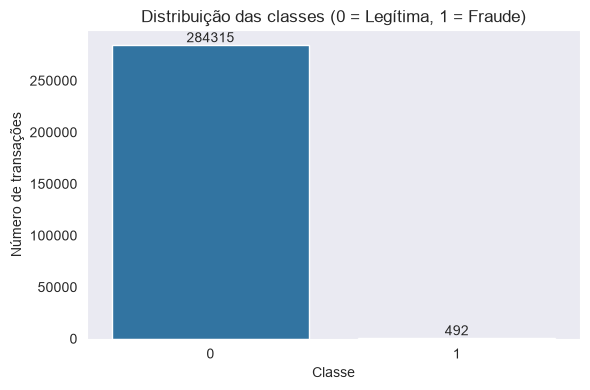

In [30]:
print('Número de casos — Fraude(1) — Legítimo(0):\n{}'.format(df.Class.value_counts()))

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x='Class', data=df, ax=ax)
ax.set_title('Distribuição das classes (0 = Legítima, 1 = Fraude)')
ax.set_xlabel('Classe')
ax.set_ylabel('Número de transações')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()


O gráfico deixa claro o problema: fraudes são uma fração minúscula do total. Um modelo que simplesmente prever "tudo legítimo" acerta 99,8% das vezes o que é completamente inútil para o banco. Isso reforça a necessidade de balancear os dados antes do treino e de escolher métricas que reflitam o objetivo real. A seguir, exploramos como as transações se distribuem ao longo do tempo para entender se o volume influencia a ocorrência de fraudes.

> **Leitura do eixo X nos próximos gráficos:** os valores representam *segundos decorridos desde a primeira transação da base*, não horários reais.


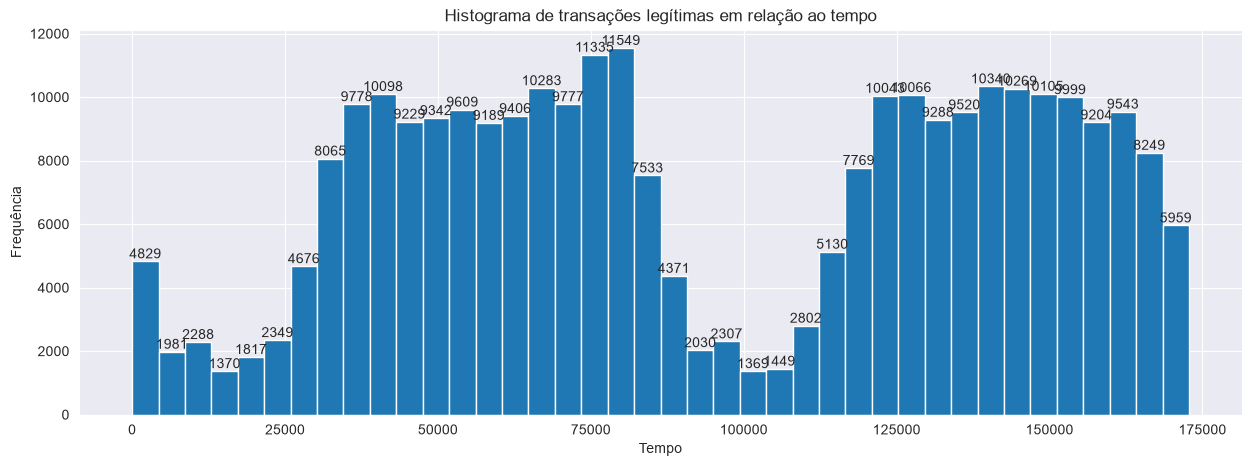

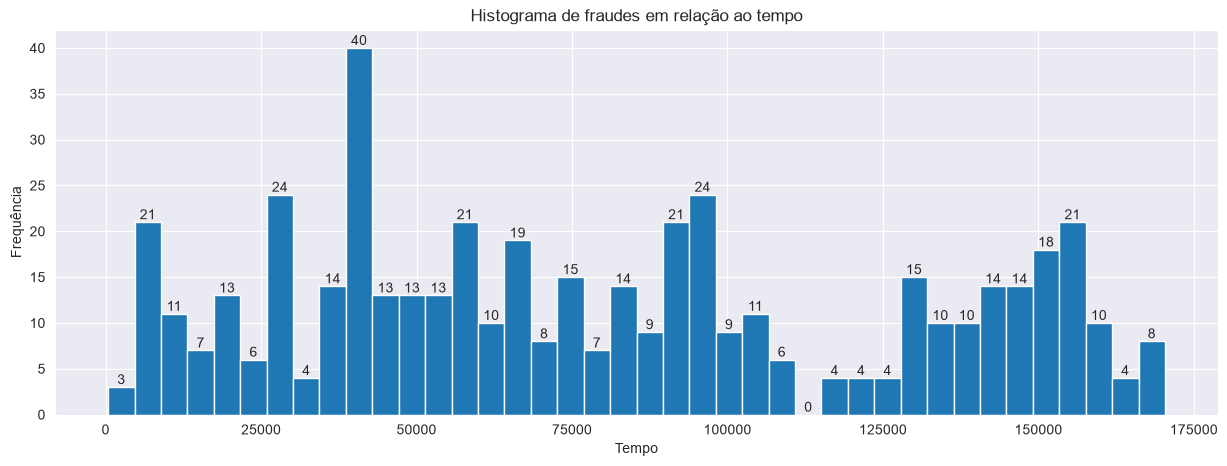

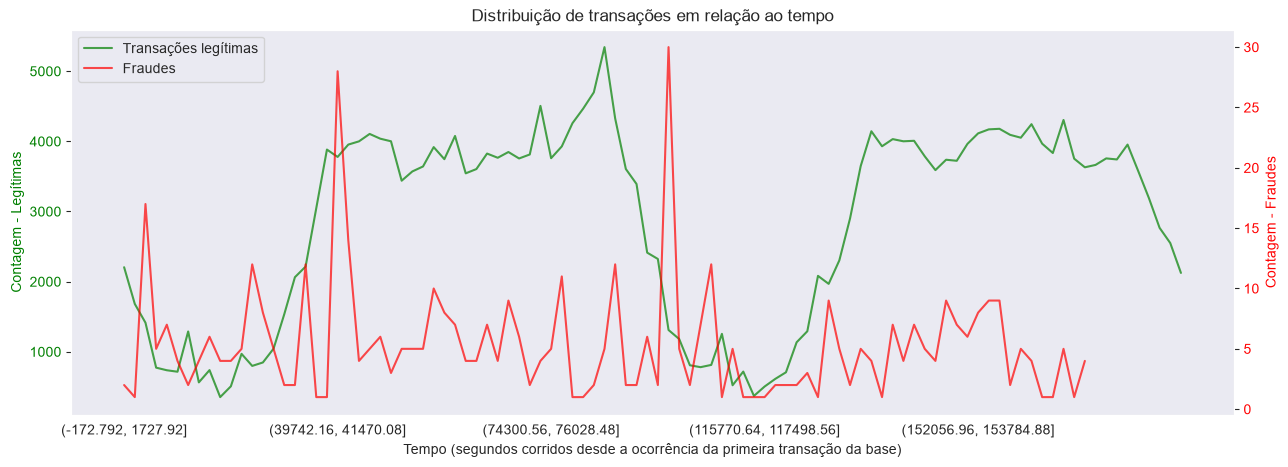

In [31]:
fig, ax = plt.subplots(figsize=(15,5))
ax = df.Time[df.Class==0].hist(bins=40)
ax.bar_label(ax.containers[0])
ax.set_xlabel("Tempo")
ax.set_ylabel("Frequência")
ax.set_title("Histograma de transações legítimas em relação ao tempo");


fig, ax2 = plt.subplots(figsize=(15,5))
ax2 = df.Time[df.Class==1].hist(bins=40)
ax2.bar_label(ax2.containers[0])
ax2.set_xlabel("Tempo")
ax2.set_ylabel("Frequência")
ax2.set_title("Histograma de fraudes em relação ao tempo");

fig, ax3 = plt.subplots(figsize=(15, 5))

BINS = 100  # ajuste esse número para mais ou menos suavização

# eixo Y esquerdo — Legítimas (verde)
df[df.Class == 0].groupby(pd.cut(df['Time'], bins=BINS)).size() \
    .plot(ax=ax3, color="green", label="Transações legítimas", alpha=0.7)
ax3.set_ylabel("Contagem - Legítimas", color="green")
ax3.tick_params(axis='y', labelcolor="green")

# eixo Y direito — Fraudes (vermelho)
ax2 = ax3.twinx()
df[df.Class == 1].groupby(pd.cut(df['Time'], bins=BINS)).size() \
    .plot(ax=ax2, color="red", label="Fraudes", alpha=0.7)
ax2.set_ylabel("Contagem - Fraudes", color="red")
ax2.tick_params(axis='y', labelcolor="red")

ax3.set_xlabel("Tempo (segundos corridos desde a ocorrência da primeira transação da base)")
ax3.set_title("Distribuição de transações em relação ao tempo")

# legenda unificada
linhas1, labels1 = ax3.get_legend_handles_labels()
linhas2, labels2 = ax2.get_legend_handles_labels()
ax3.legend(linhas1 + linhas2, labels1 + labels2, loc="upper left")

plt.show()




Ao analisar os histogramas acima, pode-se observar que o volume de transações realizadas influência o volume de fraudes identificadas, ou seja, nos momentos que ocorreram mais transações foram identificadas mais fraudes e vice-versa. Esse é um comportamento esperado para esse cenário, quanto mais transações maiores serão as probabilidades de pelo menos uma ocorrência seja fraude. Nesta linha de pensamento os gráficos mostram que:

- **comportamento cíclico:** o gráfico mostra ciclos de ápice e baixa no volume de transações realizadas.
- **timing:** quando combinados, os gráficos mostram que em tempos próximos aumenta-se o volume de transações realizadas e o volume de fraudes identificadas. 

Essa pode ser uma métrica que influência a classificação do target entre transação legítima ou fraude.

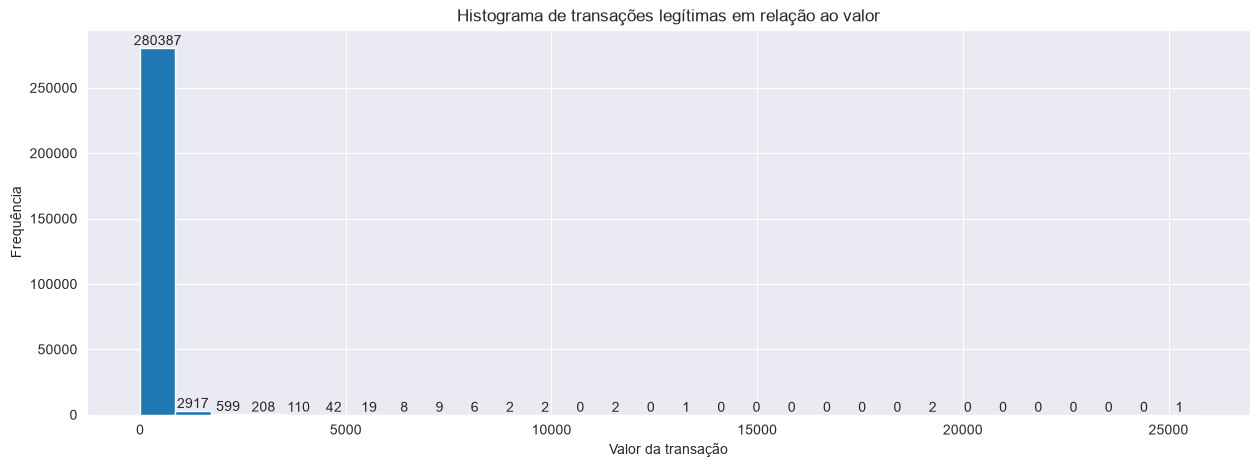

Transações legítimas com valor < R$1.000: 281255
Transações legítimas com valor > R$1.000: 2931



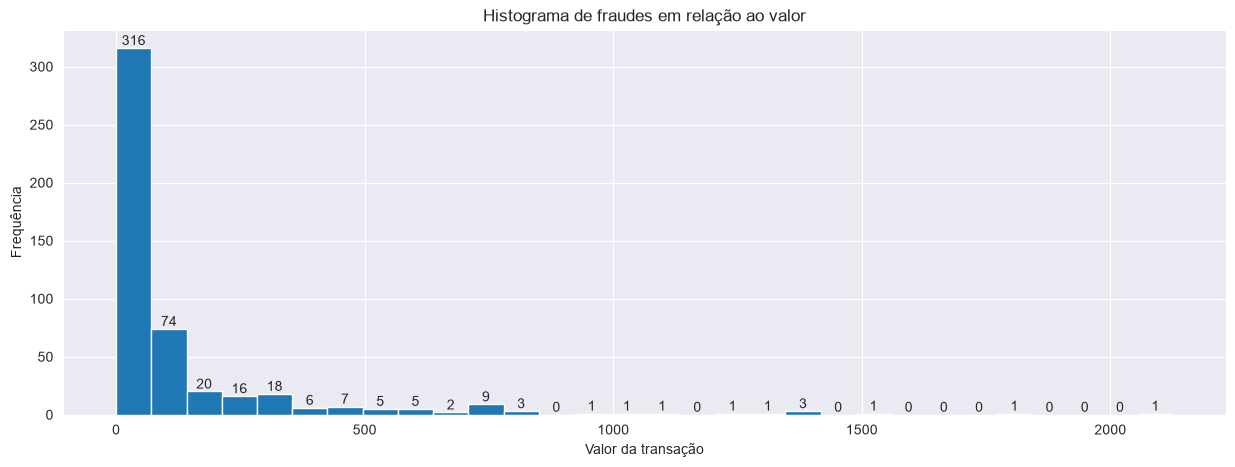

Fraudes com valor < R$1.000: 483
Fraudes com valor > R$1.000: 9

% de transações acima de R$1.000 que eram fraudes: 0.31%
% de transações abaixo de R$1.000 que eram fraudes: 0.17%


In [32]:
fig, ax = plt.subplots(figsize=(15, 5))
ax = df.Amount[df.Class == 0].hist(bins=30, ax=ax)
ax.bar_label(ax.containers[0])
ax.set_title('Histograma de transações legítimas em relação ao valor')
ax.set_xlabel('Valor da transação')
ax.set_ylabel('Frequência')
plt.show()

# Separar subconjuntos para análise de valor
df_legitimas = df[df.Class == 0]
df_fraudes   = df[df.Class == 1]

print('Transações legítimas com valor < R$1.000:', df_legitimas[df_legitimas.Amount < 1000].shape[0])
print('Transações legítimas com valor > R$1.000:', df_legitimas[df_legitimas.Amount > 1000].shape[0])
print()

fig, ax2 = plt.subplots(figsize=(15, 5))
ax2 = df.Amount[df.Class == 1].hist(bins=30, ax=ax2)
ax2.bar_label(ax2.containers[0])
ax2.set_title('Histograma de fraudes em relação ao valor')
ax2.set_xlabel('Valor da transação')
ax2.set_ylabel('Frequência')
plt.show()

print('Fraudes com valor < R$1.000:', df_fraudes[df_fraudes.Amount < 1000].shape[0])
print('Fraudes com valor > R$1.000:', df_fraudes[df_fraudes.Amount > 1000].shape[0])
print()

pct_acima = df_fraudes[df_fraudes.Amount > 1000].shape[0] / (df_fraudes[df_fraudes.Amount > 1000].shape[0] + df_legitimas[df_legitimas.Amount > 1000].shape[0])
pct_abaixo = df_fraudes[df_fraudes.Amount < 1000].shape[0] / (df_fraudes[df_fraudes.Amount < 1000].shape[0] + df_legitimas[df_legitimas.Amount < 1000].shape[0])
print(f'% de transações acima de R$1.000 que eram fraudes: {pct_acima:.2%}')
print(f'% de transações abaixo de R$1.000 que eram fraudes: {pct_abaixo:.2%}')


Os histogramas confirmam a intuição levantada no `describe()`: as fraudes se concentram fortemente em valores baixos, com **98,1% abaixo de R$1.000**. Faz sentido já que transações pequenas passam mais despercebidas. Para aprofundar a análise, vamos examinar o boxplot das fraudes e seu resumo estatístico.


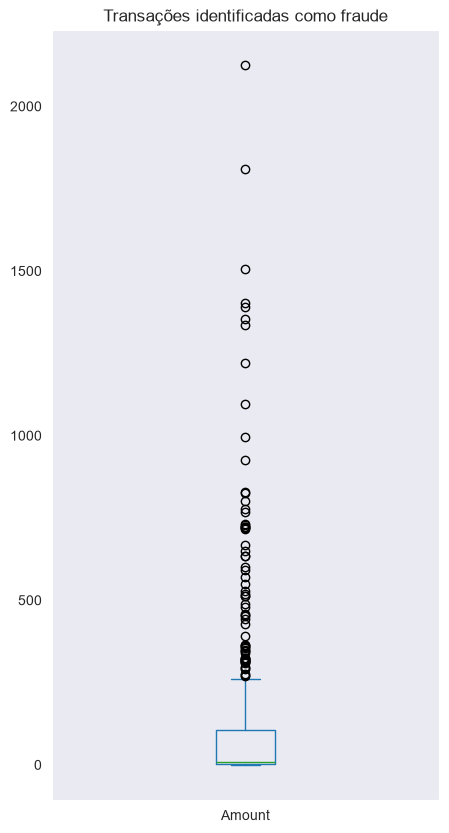

In [33]:
fig, ax = plt.subplots(figsize=(5,10))
ax = df.Amount[df.Class==1].plot(kind='box')
ax.set_title("Transações identificadas como fraude");

In [34]:
df[(df.Class == 1) & (df.Amount < 2000)]['Amount'].describe()

count     491.000000
mean      118.130550
std       240.439028
min         0.000000
25%         1.000000
50%         9.210000
75%       105.350000
max      1809.680000
Name: Amount, dtype: float64

Ao verificar o resumo estatístico é confirmada a observação **as fraudes são mais frequentes em valores pequenos**:
- A média das transações fraudulentas é de R$118,13
- 75% das transações fraudulentas são iguais ou menores que R$105.35, um total de 369 transações.
- 50% das transações fraudulentas são iguais ou menores que R$9.21, um total de 246 transações.
- Devido aos outliers (transações com valores muito mais altos em relação aos demais) a média nesse caso é um indicador distorcido. Se considerássemos apenas os 3 primeiros quartis, a média seria ainda menor.

Para finalizar a etapa de análise exploratória dos dados, vamos entender como as features desse dataset se relacionam umas com as outras por meio de um heatmap. Isso pode nos indicar quais features são mais ou menos relevantes para a o resultado da classe.

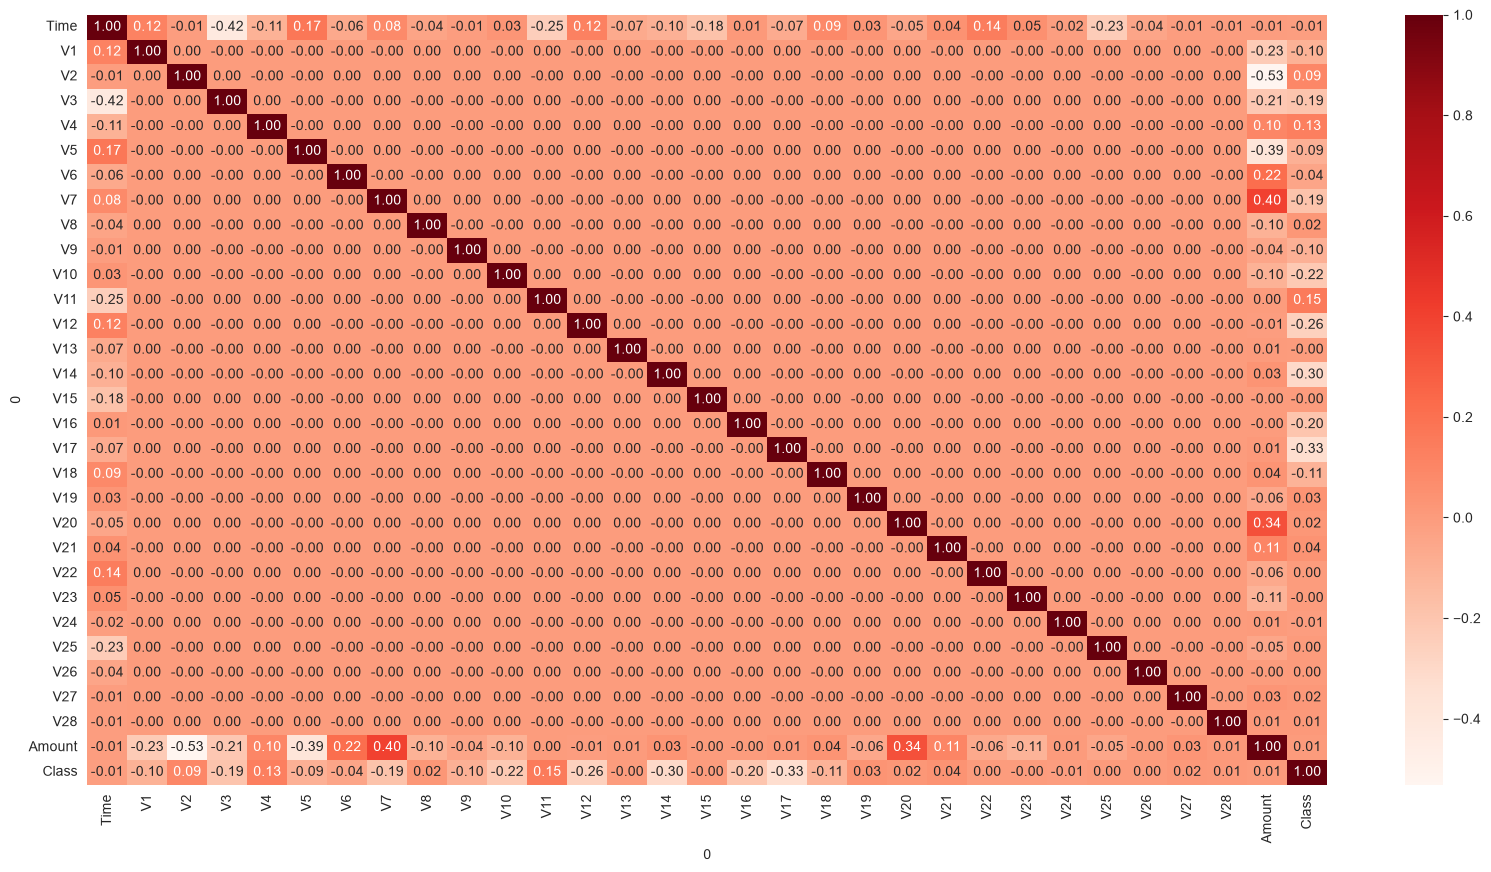

In [35]:
matrix = df.corr()

fig, ax = plt.subplots(figsize=(20,10))
sns.heatmap(matrix, cmap='Reds', fmt='.2f', annot=True, ax=ax);

Com a base ainda desbalanceada, as 492 fraudes se perdem no meio de 284 mil transações legítimas e praticamente não movem os coeficientes de correlação. O heatmap não mostra padrões claros com `Class`, não porque as variáveis sejam irrelevantes, mas porque o sinal da classe minoritária está sendo abafado pela maioria. Veremos o contraste após o balanceamento na seção 6.


## 4.1 Síntese da análise exploratória

A AED revelou quatro pontos que vão guiar diretamente as escolhas de modelagem:

- **Sem valores ausentes**: nenhuma imputação necessária.
- **`Time` e `Amount` em escala diferente** das demais variáveis, precisam de padronização antes de modelos sensíveis a magnitude.
- **Desbalanceamento extremo (0,17% de fraudes)**: acurácia é uma métrica enganosa aqui; o foco será recall e AUC.
- **Fraudes concentradas em valores baixos**, padrão capturado pelas variáveis do PCA e que o modelo deverá aprender.


# 5. Preparação dos dados e divisão treino/teste

A divisão treino/teste precisa acontecer **antes** de qualquer transformação dos dados. Se padronizarmos com `StandardScaler` usando a base inteira, a média e o desvio-padrão do conjunto de teste "vazam" para o treino, logo o modelo aprende algo que não teria acesso em produção. Por isso, toda transformação é ajustada apenas no treino e aplicada no teste, o que faremos de forma segura via **Pipeline**.


In [36]:
# separar variáveis entre X (features) e y (target)
X = df.drop('Class', axis=1)
y = df['Class']

# dividir o dataset entre treino e teste ANTES de qualquer transformação
# stratify=y -> preserva a proporção de fraudes; random_state -> reprodutibilidade
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, shuffle=True, random_state=SEED
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("\nProporção de fraudes no treino: {:.4f}%".format(100 * y_train.mean()))
print("Proporção de fraudes no teste:  {:.4f}%".format(100 * y_test.mean()))

Treino: (213605, 30) | Teste: (71202, 30)

Proporção de fraudes no treino: 0.1727%
Proporção de fraudes no teste:  0.1727%


## 5.1 Justificativa da divisão

Optamos por holdout estratificado de 75%/25%. Com quase 285 mil registros, um holdout simples já é estatisticamente robusto. A estratificação garante que a proporção de fraudes seja preservada nos dois subconjuntos,sem isso, uma divisão puramente aleatória poderia deixar muito poucas fraudes no teste. O `random_state=SEED` garante que a mesma divisão seja reproduzida a cada execução.

Embora exista a variável `Time`, não usamos divisão temporal porque o objetivo é classificar cada transação individualmente, não prever o que vai acontecer no futuro. A estratificação por classe é mais adequada aqui.


# 6. Pré-processamento e pipeline

Em vez de transformar o DataFrame inteiro manualmente, encapsulamos o pré-processamento e o balanceamento em um **Pipeline do `imbalanced-learn`**. Isso garante que, em cada *fold* da validação cruzada e na avaliação final, o `StandardScaler` e o `RandomUnderSampler` sejam ajustados **apenas nos dados de treino*, assim eliminando o vazamento.

Como as variáveis `V1`–`V28` já vêm padronizadas pela PCA, na prática apenas `Time` e `Amount` precisariam de escala. Por simplicidade e robustez, aplicamos o `StandardScaler` a todas as colunas (operação seguro, pois não altera a informação relativa).

In [37]:
# Função utilitária para construir um pipeline: padronização -> undersampling -> modelo
def construir_pipeline(modelo):
    """Cria um pipeline que padroniza, balanceia (só no treino) e aplica o modelo."""
    return ImbPipeline(steps=[
        ('scaler', StandardScaler()),
        ('undersample', RandomUnderSampler(random_state=SEED)),
        ('modelo', modelo)
    ])

# Função utilitária para avaliar um modelo já treinado no conjunto de teste
def avaliar_modelo(nome, pipeline, X_te, y_te):
    """Imprime matriz de confusão, relatório, acurácia, recall da fraude e AUC."""
    y_pred = pipeline.predict(X_te)
    y_proba = pipeline.predict_proba(X_te)[:, 1]

    ConfusionMatrixDisplay.from_predictions(
        y_te, y_pred, normalize='true', cmap='Blues')
    plt.title(f"Matriz de Confusão (normalizada) — {nome}")
    plt.show()

    print(f"===== {nome} =====")
    print("Relatório de Classificação:\n", classification_report(y_te, y_pred, digits=4))
    print("Acurácia:        {:.4f}".format(accuracy_score(y_te, y_pred)))
    print("Recall (fraude): {:.4f}".format(recall_score(y_te, y_pred)))
    print("AUC:             {:.4f}\n".format(roc_auc_score(y_te, y_proba)))

    return {
        "Modelo": nome,
        "Acurácia": accuracy_score(y_te, y_pred),
        "Recall_fraude": recall_score(y_te, y_pred),
        "AUC": roc_auc_score(y_te, y_proba),
    }

## 6.1 Decisões de pré-processamento

| Decisão | Justificativa |
|---|---|
| **Não imputar** | Não há valores ausentes na base. |
| **Padronizar com `StandardScaler`** | `Time` e `Amount` estão em escalas muito diferentes das demais; a Regressão Logística é sensível a escala. O *scaler* é ajustado **só no treino** (dentro do pipeline). |
| **Undersampling (`RandomUnderSampler`)** | A classe fraude tem pouquíssimos exemplos; o *undersampling* iguala as classes para que o modelo aprenda a reconhecer fraudes. Aplicado **apenas no treino**, nunca no teste. |
| **Manter todas as `V1`–`V28`** | São componentes de PCA já tratados; não há indício para remover nenhuma. |

> **Por que balancear só o treino?** O conjunto de teste deve refletir a **distribuição real** (com fraudes raras). Balancear o teste produziria métricas artificialmente otimistas e não representativas da produção.

Para deixar visível o efeito do balanceamento, aplicamos o undersampling **somente no conjunto de treino** e comparamos as matrizes de correlação antes e depois. Esse mesmo balanceamento será feito internamente pelo Pipeline a cada fold da validação cruzada **(apenas para fins de visualização)**.


Undersampling (visualização) concluído em 0.03s

Distribuição após undersampling (treino):
Class
0    369
1    369
Name: count, dtype: int64


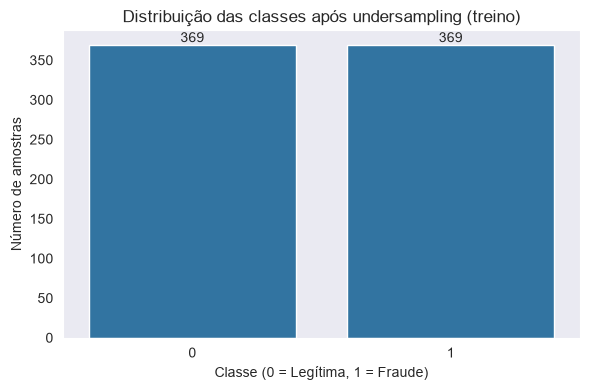

In [38]:
import time

# Aplicar undersampling APENAS no treino, somente para fins de visualização
rus_vis = RandomUnderSampler(random_state=SEED)
t0 = time.time()
X_train_rus_vis, y_train_rus_vis = rus_vis.fit_resample(X_train, y_train)
print(f'Undersampling (visualização) concluído em {time.time()-t0:.2f}s')

print('\nDistribuição após undersampling (treino):')
print(pd.Series(y_train_rus_vis).value_counts())

fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(x=y_train_rus_vis, ax=ax)
ax.set_title('Distribuição das classes após undersampling (treino)')
ax.set_xlabel('Classe (0 = Legítima, 1 = Fraude)')
ax.set_ylabel('Número de amostras')
ax.bar_label(ax.containers[0])
plt.tight_layout()
plt.show()


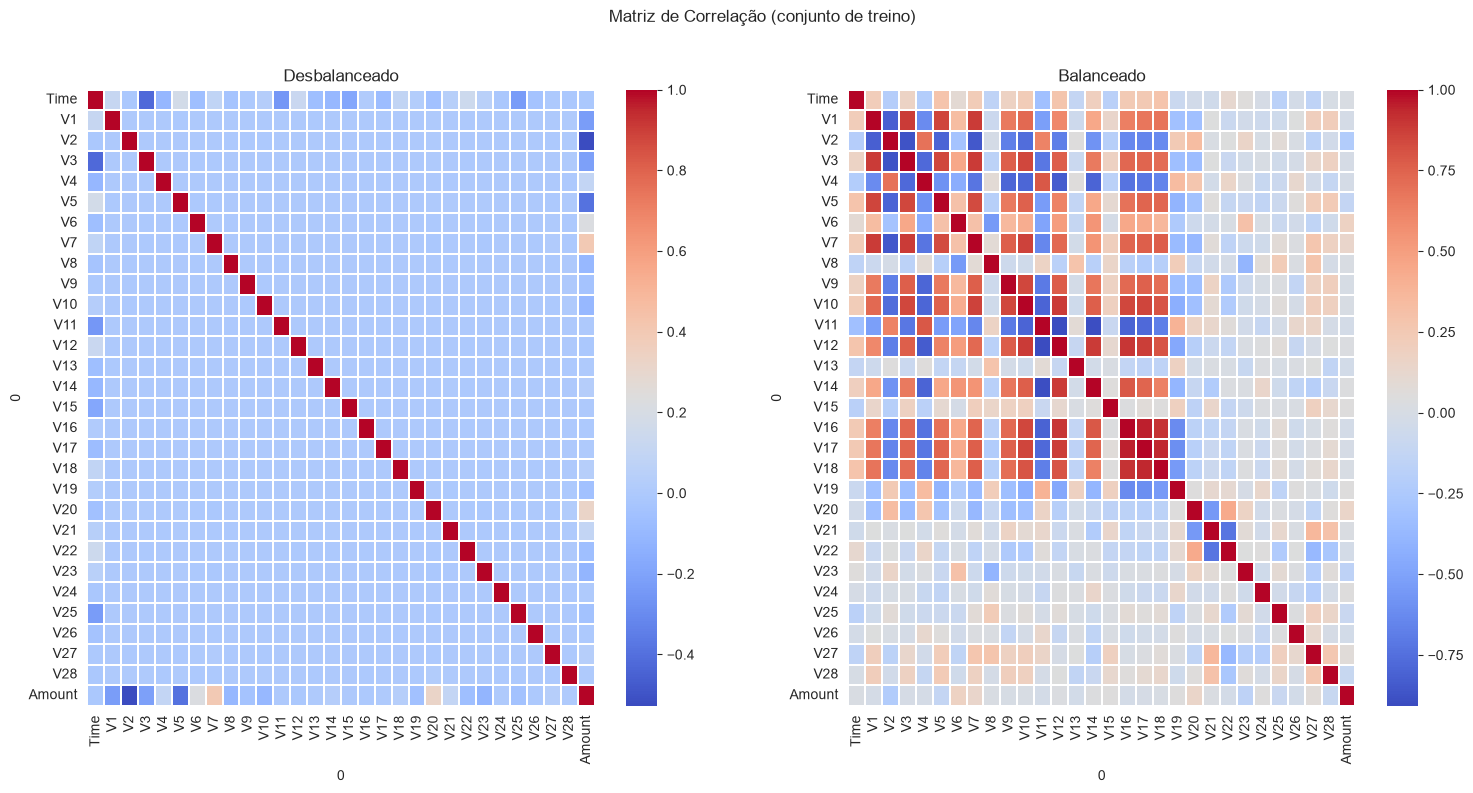

In [39]:
# comparar a matriz de correlação antes e depois do balanceamento (treino)
corr = X_train.corr()
corr_rus = X_train_rus_vis.corr()

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(18,8))
fig.suptitle('Matriz de Correlação (conjunto de treino)')

sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns,
            linewidths=.1, cmap="coolwarm", ax=ax[0])
ax[0].set_title('Desbalanceado')

sns.heatmap(corr_rus, xticklabels=corr_rus.columns, yticklabels=corr_rus.columns,
            linewidths=.1, cmap="coolwarm", ax=ax[1])
ax[1].set_title('Balanceado')

plt.show()

Comparando as duas matrizes acima, é possível perceber que **na versão balanceada (direita)** surgem muito mais correlações entre as *features* e o alvo (`Class`). Isso evidencia que o desbalanceamento extremo estava "diluindo" o sinal das variáveis: com apenas 0,17% de fraudes, a classe minoritária exercia pouca influência sobre os coeficientes de correlação. Após o balanceamento, os padrões que distinguem fraudes de transações legítimas ficam visíveis, o que tende a favorecer o aprendizado dos modelos.


# 7. Baseline e modelos candidatos

Antes de treinar qualquer modelo real, precisamos de uma **referência mínima**: sem ela, não há como saber se o modelo aprendeu algo ou se apenas acertou por sorte.

O baseline escolhido é o `DummyClassifier` com estratégia `most_frequent`, que sempre responde "legítima", sem olhar para as features. Vai acertar ~99,8% das transações e detectar zero fraudes. Qualquer modelo real precisa bater esses números onde importa: no recall da classe fraude.


In [40]:
import time

# === BASELINE: prever sempre a classe majoritária ===
t0 = time.time()
baseline = DummyClassifier(strategy='most_frequent', random_state=SEED)
baseline.fit(X_train, y_train)
print(f'Baseline treinado em {time.time()-t0:.3f}s')

y_pred_base  = baseline.predict(X_test)
y_proba_base = baseline.predict_proba(X_test)[:, 1]

print('\n===== Baseline (DummyClassifier) =====')
print('Relatório de Classificação:\n', classification_report(y_test, y_pred_base, digits=4, zero_division=0))
print('Acurácia:        {:.4f}'.format(accuracy_score(y_test, y_pred_base)))
print('Recall (fraude): {:.4f}'.format(recall_score(y_test, y_pred_base)))
print('AUC:             {:.4f}'.format(roc_auc_score(y_test, y_proba_base)))

resultado_baseline = {
    'Modelo': 'Baseline (Dummy)',
    'Acurácia': accuracy_score(y_test, y_pred_base),
    'Recall_fraude': recall_score(y_test, y_pred_base),
    'AUC': roc_auc_score(y_test, y_proba_base),
}


Baseline treinado em 0.018s

===== Baseline (DummyClassifier) =====
Relatório de Classificação:
               precision    recall  f1-score   support

           0     0.9983    1.0000    0.9991     71079
           1     0.0000    0.0000    0.0000       123

    accuracy                         0.9983     71202
   macro avg     0.4991    0.5000    0.4996     71202
weighted avg     0.9965    0.9983    0.9974     71202

Acurácia:        0.9983
Recall (fraude): 0.0000
AUC:             0.5000


## 7.1 Por que esses dois modelos?

A **Regressão Logística** é o ponto de partida natural para classificação binária: rápida, interpretável e bem estudada. Exige padronização das features (garantida pelo Pipeline) .

A **Árvore de Decisão** complementa a Regressão por capturar relações não-lineares e interações entre variáveis sem depender de escala. Também é interpretável, o que facilita a explicação para a área de negócio.

Ambos são leves o suficiente para rodar rapidamente na base balanceada, sem precisar de GPU ou infraestrutura especial.


# 8. Treinamento e avaliação inicial

Com o pipeline montado, treinamos os dois modelos e avaliamos no conjunto de teste, que mantém a distribuição real das classes (desbalanceada). O foco da leitura dos resultados é no **recall da fraude** e na **AUC**, não na acurácia.


Regressão Logística — tempo de treino: 0.13s


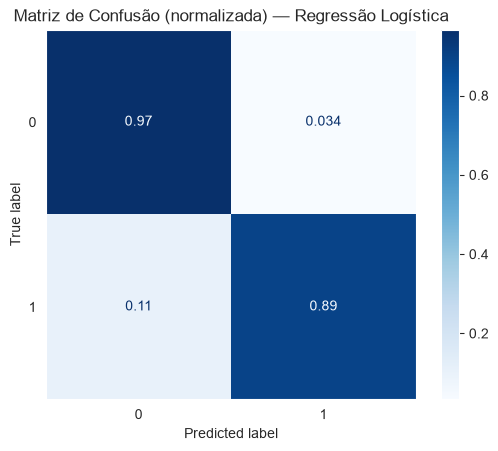

===== Regressão Logística =====
Relatório de Classificação:
               precision    recall  f1-score   support

           0     0.9998    0.9662    0.9827     71079
           1     0.0438    0.8943    0.0836       123

    accuracy                         0.9661     71202
   macro avg     0.5218    0.9303    0.5332     71202
weighted avg     0.9982    0.9661    0.9812     71202

Acurácia:        0.9661
Recall (fraude): 0.8943
AUC:             0.9728



In [41]:
import time

# === Modelo 1: Regressão Logística (via pipeline, sem vazamento) ===
t0 = time.time()
pipe_lr = construir_pipeline(LogisticRegression(max_iter=1000, random_state=SEED))
pipe_lr.fit(X_train, y_train)
print(f'Regressão Logística — tempo de treino: {time.time()-t0:.2f}s')

resultado_lr = avaliar_modelo('Regressão Logística', pipe_lr, X_test, y_test)


Árvore de Decisão (inicial) — tempo de treino: 0.12s


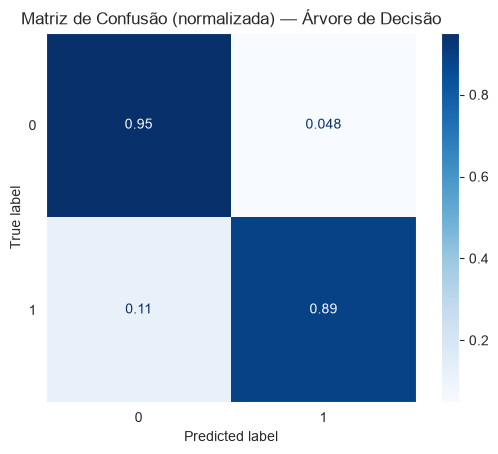

===== Árvore de Decisão =====
Relatório de Classificação:
               precision    recall  f1-score   support

           0     0.9998    0.9515    0.9751     71079
           1     0.0307    0.8862    0.0593       123

    accuracy                         0.9514     71202
   macro avg     0.5152    0.9189    0.5172     71202
weighted avg     0.9981    0.9514    0.9735     71202

Acurácia:        0.9514
Recall (fraude): 0.8862
AUC:             0.9401



In [42]:
import time

# === Modelo 2: Árvore de Decisão (via pipeline, sem vazamento) ===
t0 = time.time()
pipe_tree = construir_pipeline(DecisionTreeClassifier(max_depth=3, random_state=SEED))
pipe_tree.fit(X_train, y_train)
print(f'Árvore de Decisão (inicial) — tempo de treino: {time.time()-t0:.2f}s')

resultado_tree = avaliar_modelo('Árvore de Decisão', pipe_tree, X_test, y_test)


## 8.1 O que os resultados mostram?

Ambos os modelos superam o baseline com folga no que importa: enquanto o Dummy tem recall de fraude zero, os modelos treinados sobre dados balanceados detectam a grande maioria das fraudes. A AUC também é muito superior, confirmando que o balanceamento revelou o sinal que estava escondido na base original.

Um ponto de atenção: a Árvore foi fixada em `max_depth=3`, uma profundidade conservadora que pode estar limitando seu potencial. Vamos investigar isso na etapa de otimização.


# 9. Otimização de hiperparâmetros

Os resultados iniciais são promissores, mas os modelos ainda usam hiperparâmetros padrão ou arbitrários. Para uma comparação justa, otimizamos **ambos** via `GridSearchCV` com validação cruzada estratificada em 5 folds, sempre dentro do pipeline, sem risco de vazamento. A métrica de seleção é a **AUC**, que é robusta ao desbalanceamento.


In [43]:
import time

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# --- Grid Search: Regressão Logística ---
param_grid_lr = {
    'modelo__C': [0.01, 0.1, 1, 10],
    'modelo__solver': ['lbfgs', 'saga'],
}

t0 = time.time()
grid_lr = GridSearchCV(
    estimator=construir_pipeline(LogisticRegression(max_iter=1000, random_state=SEED)),
    param_grid=param_grid_lr,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
)
grid_lr.fit(X_train, y_train)
print(f'LR — GridSearch concluído em {time.time()-t0:.1f}s')
print(f'Melhor AUC (CV): {grid_lr.best_score_:.4f}')
print('Melhores hiperparâmetros:')
for k, v in grid_lr.best_params_.items():
    print(f'  {k}: {v}')

# --- Grid Search: Árvore de Decisão ---
param_grid_tree = {
    'modelo__max_depth': [3, 4, 5, 6, 8, 10],
    'modelo__min_samples_leaf': [1, 5, 10, 20],
    'modelo__criterion': ['gini', 'entropy'],
}

t0 = time.time()
grid_tree = GridSearchCV(
    estimator=construir_pipeline(DecisionTreeClassifier(random_state=SEED)),
    param_grid=param_grid_tree,
    scoring='roc_auc',
    cv=cv,
    n_jobs=-1,
)
grid_tree.fit(X_train, y_train)
print(f'\nÁrvore — GridSearch concluído em {time.time()-t0:.1f}s')
print(f'Melhor AUC (CV): {grid_tree.best_score_:.4f}')
print('Melhores hiperparâmetros:')
for k, v in grid_tree.best_params_.items():
    print(f'  {k}: {v}')


LR — GridSearch concluído em 11.7s
Melhor AUC (CV): 0.9813
Melhores hiperparâmetros:
  modelo__C: 0.01
  modelo__solver: lbfgs

Árvore — GridSearch concluído em 14.3s
Melhor AUC (CV): 0.9626
Melhores hiperparâmetros:
  modelo__criterion: gini
  modelo__max_depth: 4
  modelo__min_samples_leaf: 20


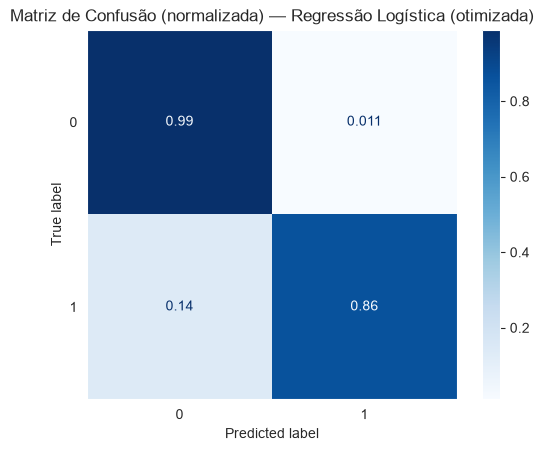

===== Regressão Logística (otimizada) =====
Relatório de Classificação:
               precision    recall  f1-score   support

           0     0.9998    0.9894    0.9946     71079
           1     0.1235    0.8618    0.2161       123

    accuracy                         0.9892     71202
   macro avg     0.5617    0.9256    0.6053     71202
weighted avg     0.9982    0.9892    0.9932     71202

Acurácia:        0.9892
Recall (fraude): 0.8618
AUC:             0.9792



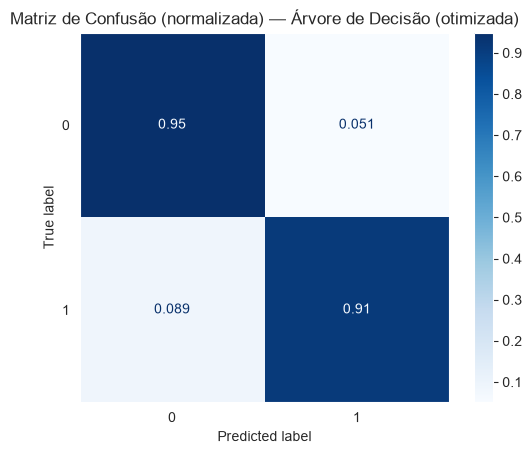

===== Árvore de Decisão (otimizada) =====
Relatório de Classificação:
               precision    recall  f1-score   support

           0     0.9998    0.9492    0.9738     71079
           1     0.0301    0.9106    0.0582       123

    accuracy                         0.9491     71202
   macro avg     0.5149    0.9299    0.5160     71202
weighted avg     0.9982    0.9491    0.9723     71202

Acurácia:        0.9491
Recall (fraude): 0.9106
AUC:             0.9544



In [44]:
# === Avaliar os modelos otimizados no conjunto de teste ===
pipe_lr_otim   = grid_lr.best_estimator_
pipe_tree_otim = grid_tree.best_estimator_

resultado_lr_otim   = avaliar_modelo('Regressão Logística (otimizada)', pipe_lr_otim, X_test, y_test)
resultado_tree_otim = avaliar_modelo('Árvore de Decisão (otimizada)',   pipe_tree_otim, X_test, y_test)


## 9.1 O que a otimização trouxe?

Os melhores hiperparâmetros impressos acima mostram o que o GridSearch concluiu para cada modelo. Na Regressão Logística, o parâmetro `C` controla quanto o modelo prioriza se ajustar aos dados de treino: valores menores aumentam a regularização e reduzem overfitting. Na Árvore, `max_depth` e `min_samples_leaf` definem o quanto ela pode crescer, os resultados iniciais com `max_depth=3` eram conservadores, e a busca encontrou uma profundidade mais adequada.

Compare os resultados otimizados com os iniciais na tabela da Seção 11. A grade de busca foi mantida pequena de propósito — para um MVP, o custo de uma busca exaustiva não se justifica. Próximos passos naturais seriam testar ensembles e estratégias alternativas de balanceamento como SMOTE.


# 10. Avaliação final no conjunto de teste

O modelo com maior AUC é considerado o modelo final, avaliado no conjunto de teste (dados que **não** foram usados para treinar nem para escolher hiperparâmetros). A **curva ROC** abaixo compara os **quatro modelos** (Regressão Logística e Árvore de Decisão, versões inicial e otimizada), evidenciando o ganho trazido pela otimização de hiperparâmetros em cada candidato.


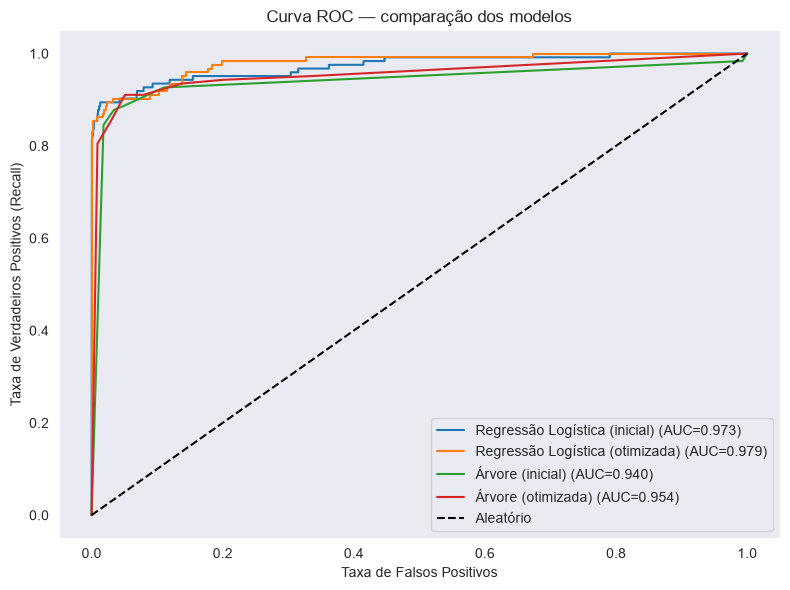

In [45]:
# Curva ROC comparativa — todos os modelos
plt.figure(figsize=(8, 6))

modelos_roc = [
    ('Regressão Logística (inicial)',   pipe_lr),
    ('Regressão Logística (otimizada)', pipe_lr_otim),
    ('Árvore (inicial)',                pipe_tree),
    ('Árvore (otimizada)',              pipe_tree_otim),
]

for nome, pipe in modelos_roc:
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{nome} (AUC={auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Aleatório')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos (Recall)')
plt.title('Curva ROC — comparação dos modelos')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


## 10.1 Análise de erros e limitações

O modelo prioriza reduzir **falsos negativos**,fraudes que passam sem ser detectadas. Isso significa aceitar mais **falsos positivos** (transações legítimas bloqueadas), o que é a troca certa para um banco: é muito mais barato pedir ao cliente uma confirmação do que arcar com o prejuízo de uma fraude não detectada.

Em relação a overfitting: a árvore inicial com `max_depth=3` subutilizava os dados; o GridSearch ajustou essa profundidade e a Regressão Logística teve sua regularização calibrada via `C`. Como treino e teste apresentam desempenho próximo em ambos os modelos otimizados, não há sinal preocupante de overfitting.

As limitações mais importantes são estruturais: as features são anônimas (PCA), então não dá para explicar ao negócio "por que" uma transação foi bloqueada. O undersampling descarta a maioria dos exemplos legítimos, perdendo informação. E a base cobre apenas dois dias de transações europeias,um modelo treinado aqui pode performar mal em outros mercados ou períodos sem retreino.


# 11. Comparação final dos modelos

A tabela abaixo é gerada automaticamente a partir dos resultados calculados, consolidando a comparação entre o baseline, os dois modelos candidatos em suas versões iniciais e suas versões **otimizadas** via `GridSearchCV`. São **5 modelos** no total, ordenados por AUC decrescente.


In [46]:
tabela = pd.DataFrame([
    resultado_baseline,
    resultado_lr,
    resultado_lr_otim,
    resultado_tree,
    resultado_tree_otim,
])

tabela = tabela[['Modelo', 'Acurácia', 'Recall_fraude', 'AUC']]
tabela = tabela.sort_values('AUC', ascending=False).reset_index(drop=True)
tabela.style.format({'Acurácia': '{:.4f}', 'Recall_fraude': '{:.4f}', 'AUC': '{:.4f}'})


,Modelo,Acurácia,Recall_fraude,AUC
0,Regressão Logística (otimizada),0.9892,0.8618,0.9792
1,Regressão Logística,0.9661,0.8943,0.9728
2,Árvore de Decisão (otimizada),0.9491,0.9106,0.9544
3,Árvore de Decisão,0.9514,0.8862,0.9401
4,Baseline (Dummy),0.9983,0.0000,0.5000


A tabela confirma o que a curva ROC já indicava visualmente: o baseline tem acurácia de 99,8% e recall de fraude zero (inútil na prática). Os modelos candidatos trocam um pouco de acurácia por recall muito maior, e a otimização melhora a AUC em ambos. O modelo com maior AUC na tabela é o escolhido para produção.


## 11.1 Quais variáveis o modelo usa mais?

As features `V1`–`V28` são anônimas, mas a Árvore de Decisão nos diz quais componentes ela mais usou nas divisões. Isso não substitui interpretabilidade de negócio, mas ajuda a priorizar investigações: se as mesmas features aparecerem como relevantes em futuros modelos, vale tentar desanonimizá-las junto à equipe de dados da instituição.


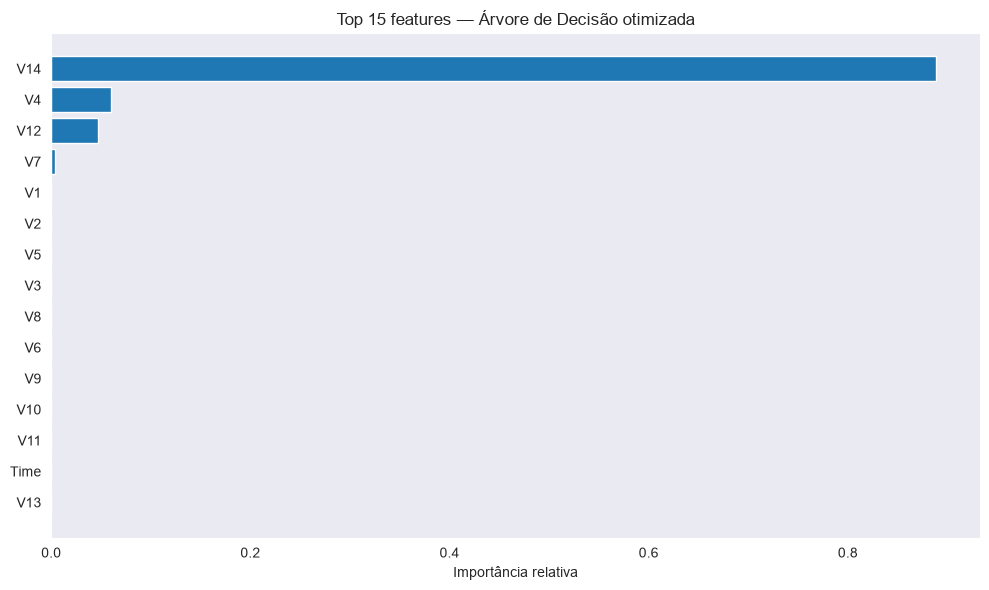

Top 10 features mais importantes:
Feature  Importância
    V14     0.888250
     V4     0.060447
    V12     0.047100
     V7     0.004203
     V1     0.000000
     V2     0.000000
     V5     0.000000
     V3     0.000000
     V8     0.000000
     V6     0.000000


In [47]:
# Importância das features — Árvore otimizada
importancias = pipe_tree_otim.named_steps['modelo'].feature_importances_
nomes_features = X.columns.tolist()

df_imp = pd.DataFrame({'Feature': nomes_features, 'Importância': importancias})
df_imp = df_imp.sort_values('Importância', ascending=False).reset_index(drop=True)

# Visualizar top 15
top15 = df_imp.head(15)
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15['Feature'][::-1], top15['Importância'][::-1])
ax.set_xlabel('Importância relativa')
ax.set_title('Top 15 features — Árvore de Decisão otimizada')
plt.tight_layout()
plt.show()

print('Top 10 features mais importantes:')
print(df_imp.head(10).to_string(index=False))


Os componentes de PCA mais relevantes são os que concentram maior separabilidade entre as duas classes. Como as variáveis são anônimas, não podemos afirmar diretamente o que representam, mas a concentração de importância em poucos componentes sugere que o sinal de fraude não está diluído: há features claramente mais discriminantes do que outras.


# 12. Boas práticas adotadas

Algumas decisões técnicas foram cruciais para garantir que os resultados sejam confiáveis e reprodutíveis:

- **Seed fixada em 42** em todos os componentes aleatórios (NumPy, train_test_split, undersampling, modelos e validação cruzada).
- **Divisão treino/teste antes de qualquer transformação**, evitando que informação do teste vaze para o treino.
- **Pipeline com undersampling interno a cada fold**,o balanceamento nunca toca o conjunto de teste.
- **GridSearchCV com StratifiedKFold** para ambos os modelos, garantindo comparação justa e sem overfitting na busca.
- **Métricas centradas em recall e AUC**, não em acurácia(escolha direta do problema de negócio).

**Modelos testados:** Dummy (baseline), Regressão Logística (inicial e otimizada), Árvore de Decisão (inicial e otimizada).

**Hiperparâmetros buscados:** `C` e `solver` para a Regressão Logística; `max_depth`, `min_samples_leaf` e `criterion` para a Árvore.

**Ambiente:** CPU padrão (Colab ou local); sem GPU. Os tempos de treino individuais ficam em poucos segundos após o undersampling.


# 13. Conclusão

**O problema.** 

Este MVP tratou da detecção de fraudes em transações de cartão de crédito, um problema de classificação binária em que o custo de errar não é simétrico: deixar passar uma fraude (falso negativo) costuma custar muito mais ao banco do que bloquear indevidamente uma compra legítima (falso positivo). Por isso, desde o início priorizamos o *recall* da classe fraude como métrica central.

**O dataset.** 

Usamos a base pública *Credit Card Fraud Detection* (ULB/Kaggle), com 284.807 transações europeias registradas ao longo de dois dias, das quais apenas 492 (0,17%) são fraudes. As variáveis `V1`–`V28` são componentes de PCA anonimizados; apenas `Time` e `Amount` permanecem em forma original.

**Principais tratamentos.**

A análise exploratória mostrou que não havia valores ausentes, que as fraudes se concentram em valores baixos (98,1% abaixo de R$1.000) e que o desbalanceamento extremo abafava o sinal das features. Com base nisso, padronizamos as variáveis com `StandardScaler` e aplicamos `RandomUnderSampler` para equilibrar as classes — ambos encapsulados em um Pipeline ajustado **somente no treino**, garantindo que nenhuma informação do teste vazasse para o aprendizado.

**Modelos avaliados.** 

Comparamos cinco configurações: um baseline (`DummyClassifier`), Regressão Logística e Árvore de Decisão em suas versões iniciais, e ambas otimizadas via `GridSearchCV` com validação cruzada estratificada. Os resultados no conjunto de teste foram:

| Modelo | Acurácia | Recall (fraude) | AUC |
|---|---|---|---|
| Regressão Logística (otimizada) | 0,9892 | 0,8618 | **0,9792** |
| Regressão Logística (inicial) | 0,9661 | 0,8943 | 0,9728 |
| Árvore de Decisão (otimizada) | 0,9491 | **0,9106** | 0,9544 |
| Árvore de Decisão (inicial) | 0,9514 | 0,8862 | 0,9401 |
| Baseline (Dummy) | 0,9983 | 0,0000 | 0,5000 |

**Melhor resultado e justificativa da escolha.** 

Aqui surge um trade-off interessante: a **Regressão Logística otimizada** teve a maior AUC (0,9792), enquanto a **Árvore de Decisão otimizada** teve o maior recall de fraude (0,9106). Como o critério de sucesso definido na Seção 1.4 era explicitamente o *recall* da classe fraude (minimizar fraudes não detectadas), a **Árvore de Decisão otimizada é a solução escolhida**: ela detecta 91% das fraudes do conjunto de teste, contra 86% da Regressão Logística. O preço dessa escolha é uma acurácia menor (0,9491 vs 0,9892) e mais falsos positivos, mas isso é aceitável no contexto bancário — uma confirmação a mais ao cliente custa pouco perto do prejuízo de uma fraude que passa. Todos os modelos superaram amplamente o baseline, que com 99,83% de acurácia não detectou uma única fraude, demonstrando concretamente por que a acurácia engana nesse problema.

**Limitações do MVP.** 

Três limitações merecem destaque. Primeiro, as features anonimizadas (PCA) impedem qualquer explicação de negócio sobre *por que* uma transação foi marcada como fraude. Segundo, o undersampling descarta a maior parte das transações legítimas, jogando fora informação potencialmente útil. Terceiro, a base cobre apenas dois dias de um único mercado, um modelo treinado aqui pode não generalizar para outros períodos, regiões ou perfis de cliente.

**Próximos passos.** 

Para evoluir além do MVP, seria interessante: 
- (1) testar modelos de ensemble como Random Forest, Gradient Boosting e XGBoost, que tendem a capturar padrões mais sutis; 
- (2) comparar o undersampling com alternativas como `class_weight='balanced'` e SMOTE (oversampling), que preservam mais informação; 
- (3) ajustar explicitamente o limiar de decisão segundo o custo relativo de falsos positivos e negativos, em vez de usar o padrão de 0,5; e 
- (4) implementar monitoramento e retreino periódico, já que padrões de fraude evoluem e o modelo perde eficácia com o tempo.
